In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
master = pd.read_csv(
    "../data/processed/master_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_month_name,purchase_quarter,purchase_weekday,purchase_hour,delivery_days,delivery_delay,is_late,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category,product_volume_cm3,product_weight_kg,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,review_sentiment,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,4,Monday,10,8.0,-8.0,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,1976.0,0.50,9350.0,maua,SP,38.71,1.0,voucher,4.0,Positive,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,3,Tuesday,20,13.0,-6.0,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,4693.0,0.40,31570.0,belo horizonte,SP,141.46,1.0,boleto,4.0,Positive,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,3,Wednesday,8,9.0,-18.0,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,9576.0,0.42,14840.0,guariba,SP,179.12,3.0,credit_card,5.0,Positive,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,November,4,Saturday,19,13.0,-13.0,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,6000.0,0.45,31842.0,belo horizonte,MG,72.20,1.0,credit_card,5.0,Positive,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,February,1,Tuesday,21,2.0,-10.0,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,11475.0,0.25,8752.0,mogi das cruzes,SP,28.62,1.0,credit_card,5.0,Positive,28.62


In [5]:
print("Rows :", master.shape[0])
print("Columns :", master.shape[1])

master.info()

Rows : 113425
Columns : 46
<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  str           
 1   customer_id                    113425 non-null  str           
 2   order_status                   113425 non-null  str           
 3   order_purchase_timestamp       113425 non-null  datetime64[us]
 4   order_approved_at              113264 non-null  datetime64[us]
 5   order_delivered_carrier_date   111457 non-null  datetime64[us]
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  113425 non-null  datetime64[us]
 8   purchase_year                  113425 non-null  int64         
 9   purchase_month                 113425 non-null  int64         
 10  purchase_month_name            113425 non-null  str 

In [6]:
total_revenue = master["total_price"].sum()

print(f"Total Revenue : ${total_revenue:,.2f}")

Total Revenue : $15,843,553.24


In [7]:
total_orders = master["order_id"].nunique()

print(total_orders)

99441


In [8]:
total_customers = master["customer_unique_id"].nunique()

print(total_customers)

96096


In [9]:
aov = total_revenue / total_orders

print(f"AOV : ${aov:.2f}")

AOV : $159.33


In [10]:
monthly_sales = (
    master
    .groupby("purchase_month_name")["total_price"]
    .sum()
    .reindex([
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"
    ])
)

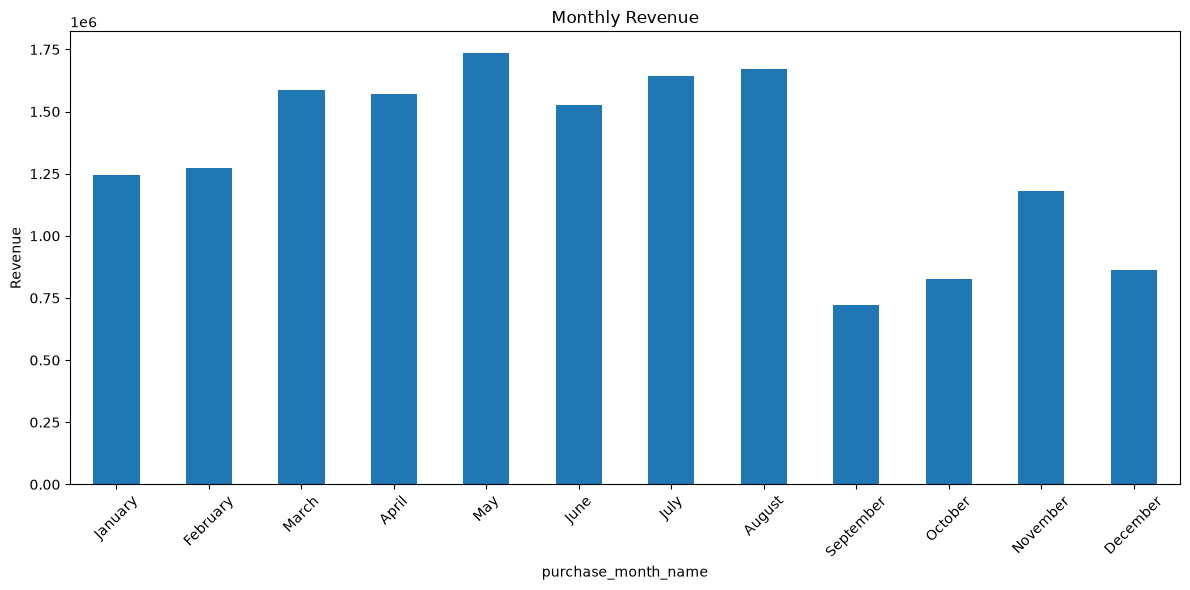

In [11]:
plt.figure(figsize=(12,6))

monthly_sales.plot(kind="bar")

plt.title("Monthly Revenue")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [12]:
top_categories = (
    master
    .groupby("category")["total_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

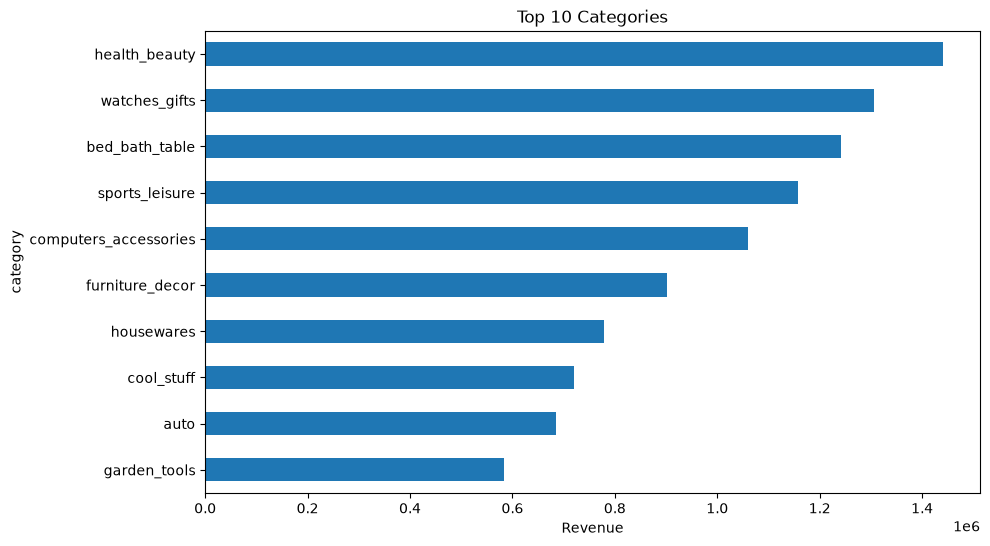

In [13]:
plt.figure(figsize=(10,6))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 10 Categories")

plt.xlabel("Revenue")

plt.show()

In [14]:
payment = (
    master["payment_type"]
    .value_counts()
)

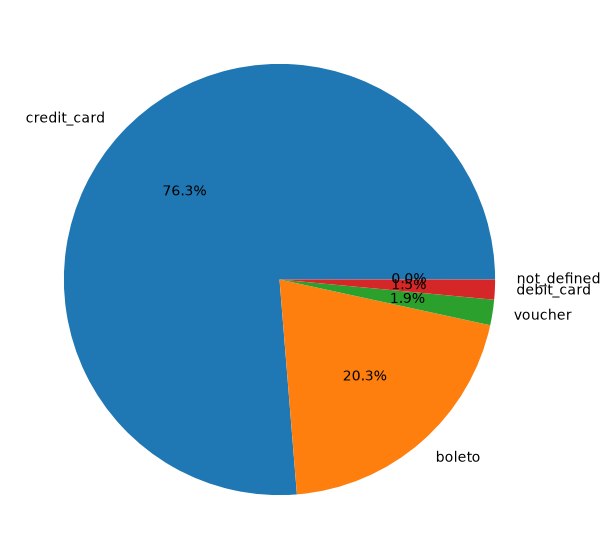

In [15]:
plt.figure(figsize=(7,7))

payment.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

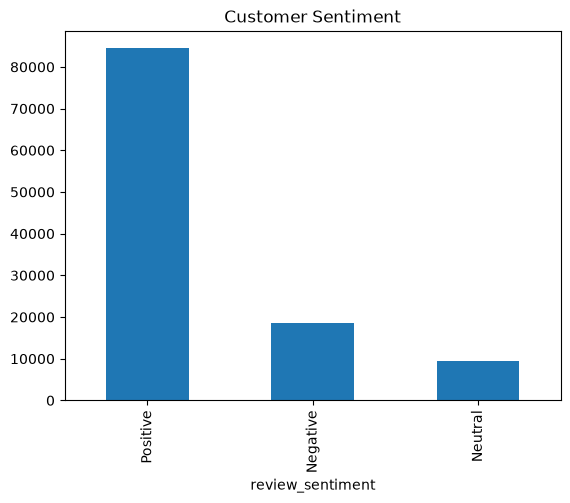

In [16]:
master["review_sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Sentiment")

plt.show()

In [17]:
master["delivery_days"].describe()

count    110196.000000
mean         12.007723
std           9.451455
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

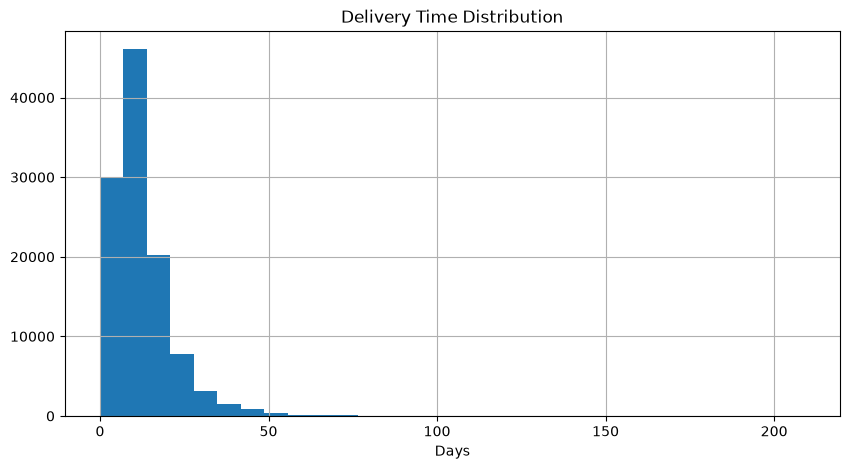

In [18]:
plt.figure(figsize=(10,5))

master["delivery_days"].dropna().hist(
    bins=30
)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.show()

In [19]:
state_sales = (
    master
    .groupby("customer_state")["total_price"]
    .sum()
    .sort_values(ascending=False)
)

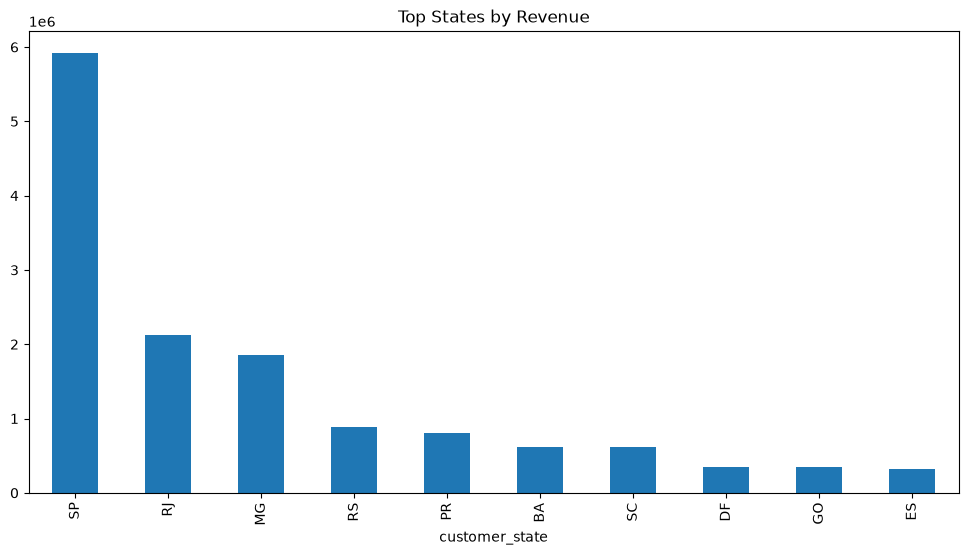

In [20]:
plt.figure(figsize=(12,6))

state_sales.head(10).plot(kind="bar")

plt.title("Top States by Revenue")

plt.show()

In [21]:
late = (
    master["is_late"]
    .mean()
)*100

print(f"Late Delivery : {late:.2f}%")

Late Delivery : 6.41%


In [22]:
kpi = pd.DataFrame({

    "Metric":[
        "Revenue",
        "Orders",
        "Customers",
        "Average Order Value",
        "Late Delivery %"
    ],

    "Value":[
        total_revenue,
        total_orders,
        total_customers,
        aov,
        late
    ]

})

kpi

,Metric,Value
0,Revenue,1.584355e+07
1,Orders,9.944100e+04
2,Customers,9.609600e+04
3,Average Order Value,1.593262e+02
4,Late Delivery %,6.405114e+00
